# Refraction ray sketches for a three-layer karst model

This notebook creates schematic ray-path diagrams for a simple three-layer model with a low-velocity cave. The rays are **illustrative ray-theory sketches**, not a numerical PyGIMLi/SPECFEM solution. Rays are straight within constant-velocity regions and change direction only at physical interfaces: layer boundaries or cave boundaries.

Geometry:
- Shot: `x = -120 m`, depth `0 m`
- Geophone: `x = +120 m`, depth `0 m`
- Layer 1: `0–10 m`, `Vp = 1600 m/s`
- Layer 2: `10–35 m`, `Vp = 3600 m/s`
- Layer 3: `35–80 m`, `Vp = 5000 m/s`
- Cave: `20 m × 20 m`, centred at `x = 0 m`, top at `15 m`, bottom at `35 m`, `Vp = 900 m/s`

The notebook produces:
1. a Snell's-law ray sketch with head waves and a ray through the cave,
2. a no-cave reference sketch,
3. a Fermat's-principle sketch showing a least-time path that avoids the slow cave.


In [52]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D

OUTDIR = Path("figures_refraction")
OUTDIR.mkdir(parents=True, exist_ok=True)


In [53]:
# -----------------------------------------------------------------------------
# Model and geometry parameters
# -----------------------------------------------------------------------------

layers = [
    dict(name="unsaturated", z_top=0.0,  z_bot=10.0, vp=1600.0, vs=800.0,  rho=2000.0, color="#fff4c7"),
    dict(name="saturated\n30% porosity", z_top=10.0, z_bot=35.0, vp=3600.0, vs=1800.0, rho=2275.0, color="#dff0d8"),
    dict(name="saturated\nlow porosity", z_top=35.0, z_bot=45.0, vp=4750.0, vs=2450.0, rho=2450.0, color="#dbeeff"),
]

cave = dict(x_min=-5.0, x_max=5.0, z_top=15.0, z_bot=20.0, vp=1500.0, rho=1000.0, color="#a6cee3")
shot = dict(x=-120.0, z=0.0)
geophone = dict(x=120.0, z=0.0)

xlim = (-150, 150)
zlim = (80, -2)  # depth increases downward


In [54]:
def setup_cross_section(ax, show_cave=True, title=None):
    """Draw the layered velocity model, optional cave, source, geophone, and axes."""
    for layer in layers:
        ax.axhspan(layer["z_top"], layer["z_bot"], color=layer["color"], alpha=0.85, zorder=0)
        ax.text(
            xlim[0] + 5,
            0.5 * (layer["z_top"] + layer["z_bot"]),
            f"{layer['name']}\n$V_P$ = {layer['vp']:.0f} m/s",
            va="center",
            ha="left",
            fontsize=9,
        )

    for z in [10, 35]:
        ax.axhline(z, color="k", linestyle="--", linewidth=1.0, alpha=0.8, zorder=1)

    if show_cave:
        rect = patches.Rectangle(
            (cave["x_min"], cave["z_top"]),
            cave["x_max"] - cave["x_min"],
            cave["z_bot"] - cave["z_top"],
            facecolor="white",
            edgecolor="black",
            linewidth=1.5,
            zorder=4,
        )
        ax.add_patch(rect)
        ax.text(
            0,
            0.5 * (cave["z_top"] + cave["z_bot"]),
            f"Cave\n20 m × 20 m\n$V_P$ = {cave['vp']:.0f} m/s",
            ha="center",
            va="center",
            fontsize=10,
            zorder=5,
        )
        ax.annotate("20 m", xy=(cave["x_min"], cave["z_bot"] + 2.5), xytext=(cave["x_max"], cave["z_bot"] + 2.5),
                    arrowprops=dict(arrowstyle="<->", color="k"), ha="center", va="bottom", fontsize=9)
        ax.annotate("20 m", xy=(cave["x_max"] + 4, cave["z_top"]), xytext=(cave["x_max"] + 4, cave["z_bot"]),
                    arrowprops=dict(arrowstyle="<->", color="k"), ha="left", va="center", fontsize=9, rotation=90)

    # Shot and receiver
    ax.scatter([shot["x"]], [shot["z"]], marker="*", s=170, color="red", edgecolor="k", zorder=10)
    ax.scatter([geophone["x"]], [geophone["z"]], marker="v", s=130, color="royalblue", edgecolor="k", zorder=10)
    ax.text(shot["x"], -1.6, "Shot", color="red", ha="center", va="bottom", fontsize=9)
    ax.text(geophone["x"], -1.6, "Geophone", color="royalblue", ha="center", va="bottom", fontsize=9)

    ax.set_xlim(*xlim)
    ax.set_ylim(*zlim)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("Depth (m)")
    ax.set_xticks([-150, -120, -100, -50, 0, 50, 100, 120, 150])
    ax.set_yticks([0, 10, 15, 35, 50])
    ax.grid(True, alpha=0.18)
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position("top")
    if title:
        ax.set_title(title, pad=16)


def draw_polyline_ray(ax, pts, color, label=None, lw=2.2, alpha=1.0, zorder=8, arrows=True):
    """Draw a piecewise-straight ray path and add small arrows along segments."""
    pts = np.asarray(pts, dtype=float)
    ax.plot(pts[:, 0], pts[:, 1], color=color, lw=lw, alpha=alpha, label=label, zorder=zorder)
    if arrows:
        for p0, p1 in zip(pts[:-1], pts[1:]):
            mid = 0.55 * p0 + 0.45 * p1
            d = p1 - p0
            if np.linalg.norm(d) == 0:
                continue
            d = d / np.linalg.norm(d)
            start = mid - 3.0 * d
            end = mid + 3.0 * d
            ax.annotate("", xy=end, xytext=start,
                        arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, mutation_scale=10),
                        zorder=zorder + 1)


def add_legend(ax):
    handles = [
        Line2D([0], [0], color="blue", lw=2.2, label="Ray passing through cave"),
        Line2D([0], [0], color="red", lw=2.2, label="Head wave along base of Layer 1"),
        Line2D([0], [0], color="green", lw=2.2, label="Head wave along base of Layer 2"),
        Line2D([0], [0], color="purple", lw=2.2, label="Refracted ray avoiding cave"),
        Line2D([0], [0], color="magenta", lw=2.2, label="Minimum-time path avoiding slow cave"),
    ]
    ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.30), ncol=2, frameon=True)


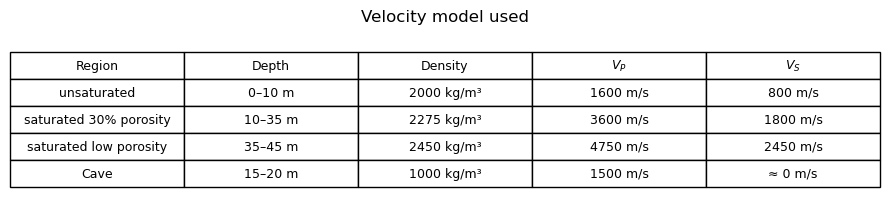

In [55]:
def plot_velocity_model_table(outfile=None):
    """Plot a compact table of the model parameters used in the ray sketches."""
    fig, ax = plt.subplots(figsize=(9, 2.3))
    ax.axis("off")
    rows = []
    for layer in layers:
        rows.append([
            layer["name"].replace("\n", " "),
            f"{layer['z_top']:.0f}–{layer['z_bot']:.0f} m",
            f"{layer['rho']:.0f} kg/m³",
            f"{layer['vp']:.0f} m/s",
            f"{layer['vs']:.0f} m/s",
        ])
    rows.append(["Cave", f"{cave['z_top']:.0f}–{cave['z_bot']:.0f} m", f"{cave['rho']:.0f} kg/m³", f"{cave['vp']:.0f} m/s", "≈ 0 m/s"])
    cols = ["Region", "Depth", "Density", "$V_P$", "$V_S$"]
    table = ax.table(cellText=rows, colLabels=cols, loc="center", cellLoc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.6)
    ax.set_title("Velocity model used")
    fig.tight_layout()
    if outfile:
        fig.savefig(outfile, dpi=220, bbox_inches="tight")
    return fig

plot_velocity_model_table(OUTDIR / "velocity_model_table.png");


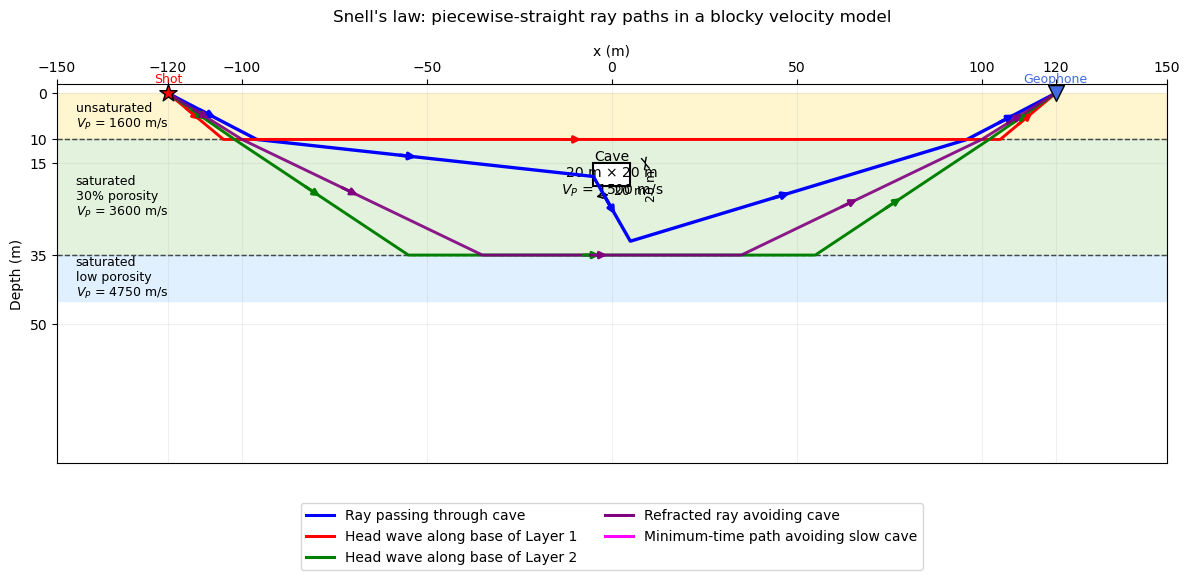

In [56]:
# -----------------------------------------------------------------------------
# Snell's-law schematic: all rays start at the same shot and arrive at the same geophone.
# Bends occur only at layer boundaries or cave boundaries.
# -----------------------------------------------------------------------------

# Head wave along the base of Layer 1 (z = 10 m): down, along interface, up.
ray_head_layer1 = [
    (shot["x"], 0),
    (-105, 10),
    (105, 10),
    (geophone["x"], 0),
]

# Head wave along the base of Layer 2 (z = 35 m): down through layer 1/2,
# along the faster lower interface, then up to the same geophone.
ray_head_layer2 = [
    (shot["x"], 0),
    (-102, 10),
    (-55, 35),
    (55, 35),
    (102, 10),
    (geophone["x"], 0),
]

# Ray passing through the slow cave. It is straight in each constant-velocity
# region and bends only at: z=10, cave entry, cave exit, z=10.
ray_through_cave = [
    (shot["x"], 0),
    (-96, 10),
    (cave["x_min"], 18),   # entry into cave at left boundary
    (cave["x_max"], 32),   # exit from cave at right boundary
    (96, 10),
    (geophone["x"], 0),
]

# A refracted ray that avoids the cave below it. This is illustrative; in a real
# solver the exact path would be found by minimizing travel time.
ray_avoid_cave = [
    (shot["x"], 0),
    (-100, 10),
    (-35, 35),
    (35, 35),
    (100, 10),
    (geophone["x"], 0),
]

fig, ax = plt.subplots(figsize=(12, 6.2))
setup_cross_section(ax, show_cave=True, title="Snell's law: piecewise-straight ray paths in a blocky velocity model")
draw_polyline_ray(ax, ray_through_cave, "blue", lw=2.4)
draw_polyline_ray(ax, ray_head_layer1, "red", lw=2.1)
draw_polyline_ray(ax, ray_head_layer2, "green", lw=2.1)
draw_polyline_ray(ax, ray_avoid_cave, "purple", lw=2.1, alpha=0.9)
add_legend(ax)
fig.tight_layout()
fig.savefig(OUTDIR / "snells_law_piecewise_rays.png", dpi=220, bbox_inches="tight")
plt.show()


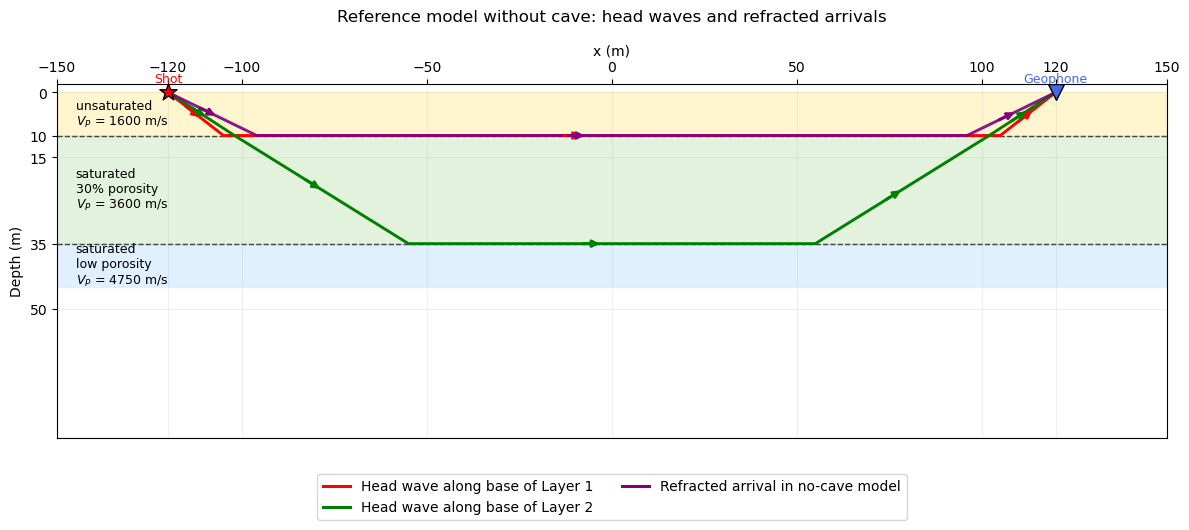

In [57]:
# -----------------------------------------------------------------------------
# Reference/no-cave schematic. No orange ray is included.
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5.6))
setup_cross_section(ax, show_cave=False, title="Reference model without cave: head waves and refracted arrivals")
draw_polyline_ray(ax, ray_head_layer1, "red", lw=2.1)
draw_polyline_ray(ax, ray_head_layer2, "green", lw=2.1)
# A simple refracted/direct body-wave path that does not involve a cave.
ray_reference_body = [(shot["x"], 0), (-96, 10), (96, 10), (geophone["x"], 0)]
draw_polyline_ray(ax, ray_reference_body, "purple", lw=2.1, alpha=0.9)
handles = [
    Line2D([0], [0], color="red", lw=2.2, label="Head wave along base of Layer 1"),
    Line2D([0], [0], color="green", lw=2.2, label="Head wave along base of Layer 2"),
    Line2D([0], [0], color="purple", lw=2.2, label="Refracted arrival in no-cave model"),
]
ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.25), ncol=2, frameon=True)
fig.tight_layout()
fig.savefig(OUTDIR / "reference_no_cave_rays.png", dpi=220, bbox_inches="tight")
plt.show()


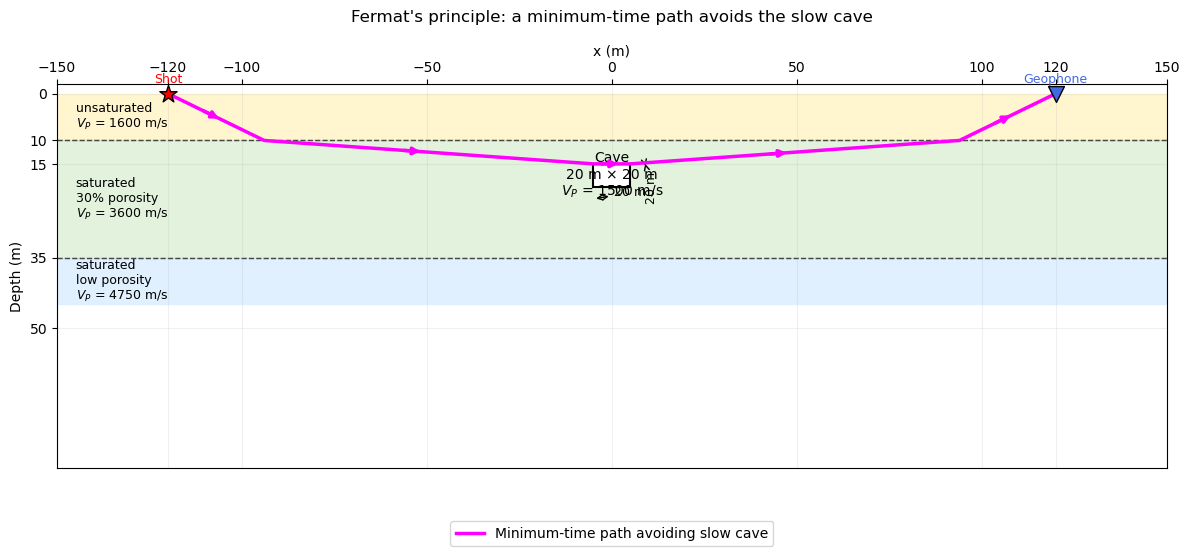

In [58]:
# -----------------------------------------------------------------------------
# Fermat's principle schematic. In a constant-velocity block model, the minimum
# time path is still piecewise straight. Here the path avoids the slow cave and
# remains mostly in faster limestone.
# -----------------------------------------------------------------------------

# A least-time-style path that skims over/around the slow cave. All bends are at
# physical interfaces: z=10 or the cave boundary/corners. No smooth bending is used.
ray_fermat_around_cave = [
    (shot["x"], 0),
    (-94, 10),
    (cave["x_min"], cave["z_top"]),
    (cave["x_max"], cave["z_top"]),
    (94, 10),
    (geophone["x"], 0),
]

fig, ax = plt.subplots(figsize=(12, 5.8))
setup_cross_section(ax, show_cave=True, title="Fermat's principle: a minimum-time path avoids the slow cave")
draw_polyline_ray(ax, ray_fermat_around_cave, "magenta", lw=2.5)
handles = [Line2D([0], [0], color="magenta", lw=2.5, label="Minimum-time path avoiding slow cave")]
ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.22), frameon=True)
fig.tight_layout()
fig.savefig(OUTDIR / "fermats_principle_path_around_cave.png", dpi=220, bbox_inches="tight")
plt.show()


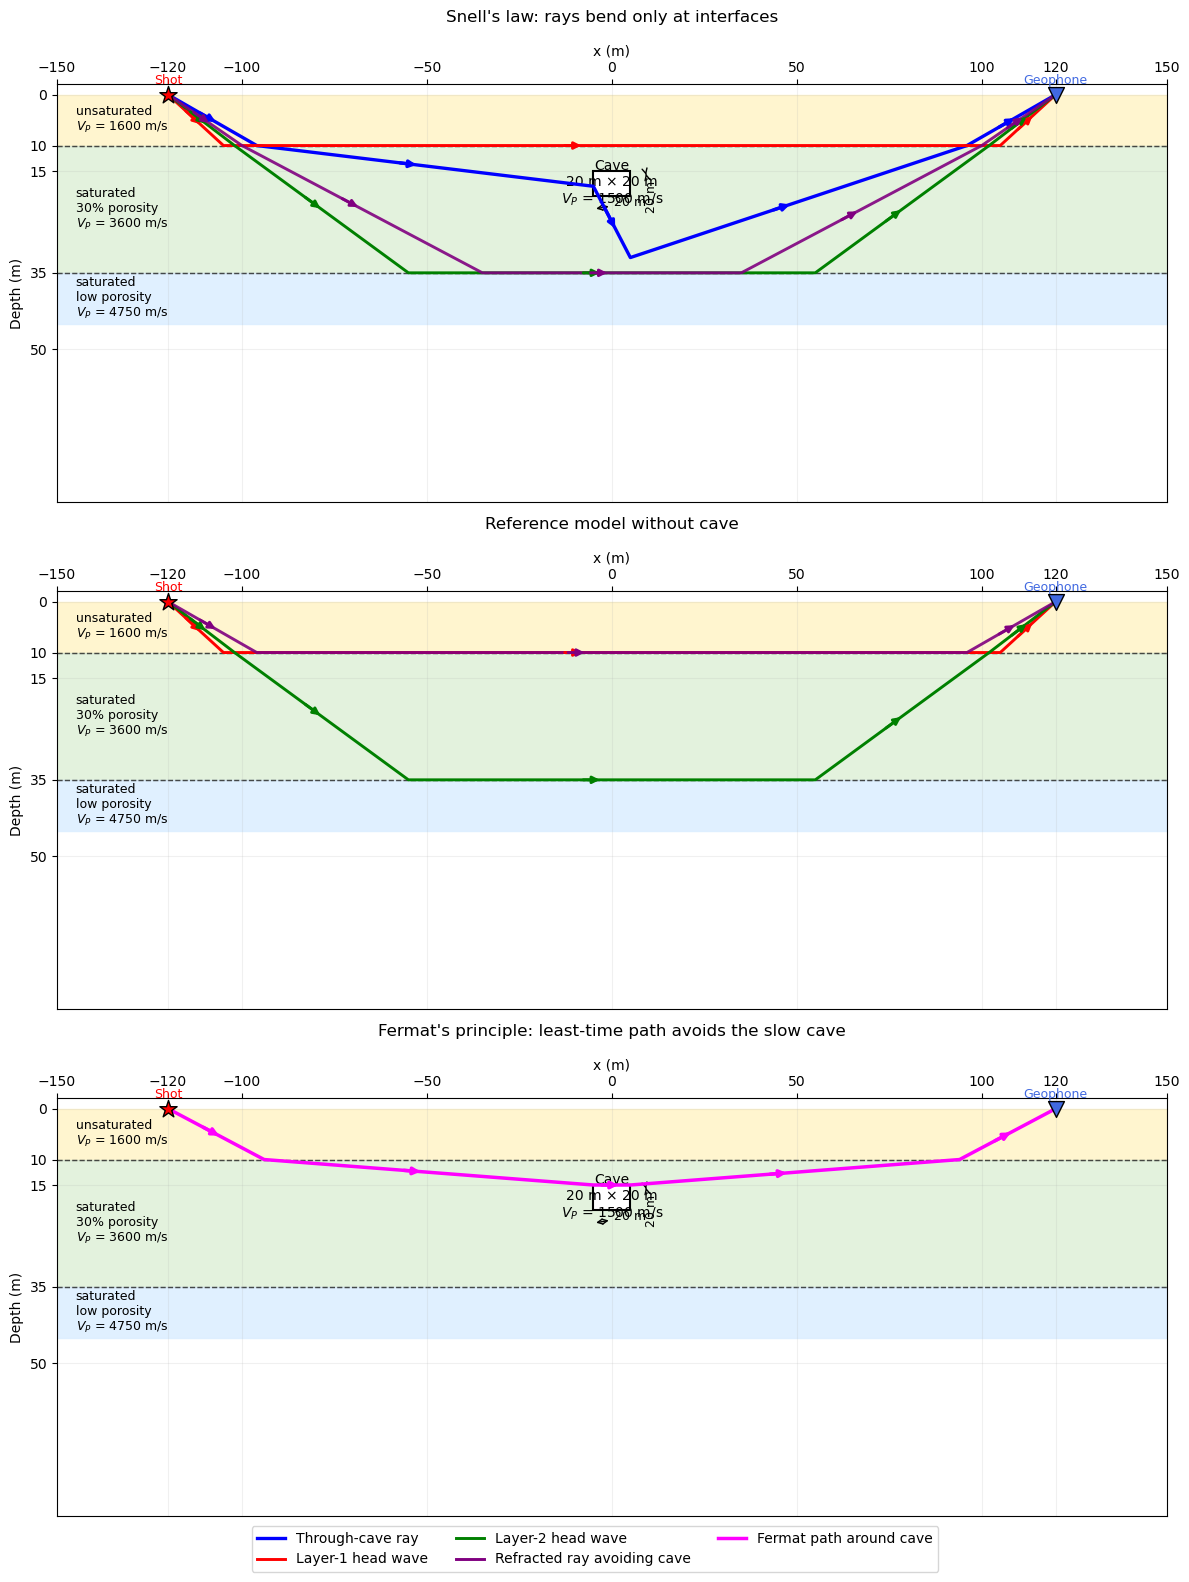

In [59]:
# -----------------------------------------------------------------------------
# Combined figure for report/slides.
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(12, 16), constrained_layout=False)

setup_cross_section(axes[0], show_cave=True, title="Snell's law: rays bend only at interfaces")
draw_polyline_ray(axes[0], ray_through_cave, "blue", lw=2.4)
draw_polyline_ray(axes[0], ray_head_layer1, "red", lw=2.1)
draw_polyline_ray(axes[0], ray_head_layer2, "green", lw=2.1)
draw_polyline_ray(axes[0], ray_avoid_cave, "purple", lw=2.1, alpha=0.9)

setup_cross_section(axes[1], show_cave=False, title="Reference model without cave")
draw_polyline_ray(axes[1], ray_head_layer1, "red", lw=2.1)
draw_polyline_ray(axes[1], ray_head_layer2, "green", lw=2.1)
draw_polyline_ray(axes[1], ray_reference_body, "purple", lw=2.1, alpha=0.9)

setup_cross_section(axes[2], show_cave=True, title="Fermat's principle: least-time path avoids the slow cave")
draw_polyline_ray(axes[2], ray_fermat_around_cave, "magenta", lw=2.5)

handles = [
    Line2D([0], [0], color="blue", lw=2.4, label="Through-cave ray"),
    Line2D([0], [0], color="red", lw=2.1, label="Layer-1 head wave"),
    Line2D([0], [0], color="green", lw=2.1, label="Layer-2 head wave"),
    Line2D([0], [0], color="purple", lw=2.1, label="Refracted ray avoiding cave"),
    Line2D([0], [0], color="magenta", lw=2.5, label="Fermat path around cave"),
]
fig.legend(handles=handles, loc="lower center", ncol=3, frameon=True, bbox_to_anchor=(0.5, 0.01))
fig.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig(OUTDIR / "combined_refraction_ray_examples.png", dpi=220, bbox_inches="tight")
plt.show()
